# Task 2 - Part A: Sentiment Analysis using Machine Learning

Baseline classical ML pipeline: data loading -> class distribution -> cleaning -> tokenization -> stopword removal -> TF-IDF -> Logistic Regression & SVM -> full metric comparison.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Dataset

In [31]:
df = pd.read_csv('train.txt', sep=';', header=None, names=['text','emotion'])
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [32]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [33]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
i = 0
for emo in unique_emotions:
    emotion_numbers[emo] = i
    i += 1

df['emotion_label'] = df['emotion'].map(emotion_numbers)
df.head()

,text,emotion,emotion_label
0,i didnt feel humiliated,sadness,0
1,i can go from feeling so hopeless to so damned...,sadness,0
2,im grabbing a minute to post i feel greedy wrong,anger,1
3,i am ever feeling nostalgic about the fireplac...,love,2
4,i am feeling grouchy,anger,1


## 2. Class Distribution

Reporting the class distribution. If the classes are imbalanced, accuracy alone can be misleading, so **F1-score (macro-averaged)** will be used as the primary metric for judging model performance instead of relying on accuracy alone.

Class distribution:
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Class proportions (%):
emotion
joy         33.51
sadness     29.16
anger       13.49
fear        12.11
love         8.15
surprise     3.58
Name: count, dtype: float64


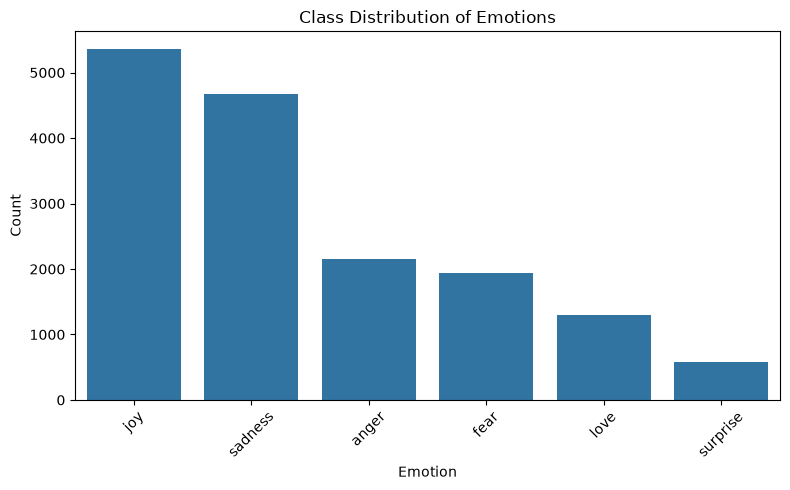


Imbalance ratio (largest/smallest class): 9.37
Dataset is IMBALANCED -> F1-score (macro) will be used as the primary evaluation metric, not accuracy alone, since accuracy can be misleadingly high for majority classes.


In [34]:
class_counts = df['emotion'].value_counts()
print('Class distribution:')
print(class_counts)
print()
print('Class proportions (%):')
print((class_counts / len(df) * 100).round(2))

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Class Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance ratio (largest/smallest class): {imbalance_ratio:.2f}')
if imbalance_ratio > 1.5:
    print('Dataset is IMBALANCED -> F1-score (macro) will be used as the primary evaluation metric, '
          'not accuracy alone, since accuracy can be misleadingly high for majority classes.')
else:
    print('Dataset is roughly balanced.')

## 3. Text Cleaning

Steps: lowercase -> remove punctuation -> remove numbers -> remove emojis/non-ascii -> remove extra whitespace -> tokenize -> remove stopwords.

In [35]:
# Step 1: Lowercase
df['text_clean'] = df['text'].apply(lambda x: x.lower())

In [36]:
# Step 2: Remove punctuation
import string
def remove_punc(txt):
    return txt.translate(str.maketrans('', '', string.punctuation))

df['text_clean'] = df['text_clean'].apply(remove_punc)

In [37]:
# Step 3: Remove numbers
def remove_numbers(txt):
    return ''.join([ch for ch in txt if not ch.isdigit()])

df['text_clean'] = df['text_clean'].apply(remove_numbers)

In [38]:
# Step 4: Remove emojis / non-ascii characters
def remove_emojis(txt):
    return ''.join([ch for ch in txt if ch.isascii()])

df['text_clean'] = df['text_clean'].apply(remove_emojis)

In [39]:
# Step 5: Remove extra whitespace (required cleaning step)
def remove_extra_whitespace(txt):
    return ' '.join(txt.split())

df['text_clean'] = df['text_clean'].apply(remove_extra_whitespace)
df[['text','text_clean']].head()

,text,text_clean
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


## 4. Tokenization

In [40]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\avnir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\avnir\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\avnir\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [41]:
# Explicit tokenization step (required)
df['tokens'] = df['text_clean'].apply(word_tokenize)
print('Example before tokenization:', df['text_clean'].iloc[1])
print('Example after tokenization:', df['tokens'].iloc[1])

Example before tokenization: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Example after tokenization: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']


## 5. Stopword Removal

In [42]:
stop_words = set(stopwords.words('english'))
print('Number of English stopwords:', len(stop_words))

Number of English stopwords: 198


In [43]:
def remove_stopwords(tokens):
    return [w for w in tokens if w not in stop_words]

df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)
df['final_text'] = df['tokens_no_stop'].apply(lambda toks: ' '.join(toks))

print('Before stopword removal:', df['tokens'].iloc[1])
print('After stopword removal :', df['tokens_no_stop'].iloc[1])

Before stopword removal: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake']
After stopword removal : ['go', 'feeling', 'hopeless', 'damned', 'hopeful', 'around', 'someone', 'cares', 'awake']


## 6. Fixed Train/Test Split

A fixed random seed (`random_state=42`) and fixed 80/20 split are used here. **This exact same split must be reused for the SVM below and for the LSTM in Part B** so that all models are compared on identical train/test data.

In [44]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    df['final_text'], df['emotion_label'],
    test_size=0.20, random_state=RANDOM_SEED, stratify=df['emotion_label']
)

print('Train size:', len(X_train), '| Test size:', len(X_test))

Train size: 12800 | Test size: 3200


## 7. TF-IDF Feature Extraction

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print('TF-IDF feature extraction details:')
print('Vocabulary size:', len(tfidf_vectorizer.vocabulary_))
print('Train matrix shape:', X_train_tfidf.shape)
print('Test matrix shape :', X_test_tfidf.shape)
print('Sample feature names:', tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF feature extraction details:
Vocabulary size: 13360
Train matrix shape: (12800, 13360)
Test matrix shape : (3200, 13360)
Sample feature names: ['aa' 'aaaand' 'aac' 'aahhh' 'ab' 'abandon' 'abandoned' 'abandoning'
 'abandonment' 'abated' 'abc' 'abdomen' 'abdominal' 'abhorrent' 'abide'
 'abilities' 'ability' 'abit' 'able' 'ableness']


## 8. Evaluation Helper

A single helper reports Accuracy, Precision, Recall and F1-score (macro-averaged, appropriate for the imbalanced multi-class setting) for any model.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f'--- {name} Results ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f} (macro)')
    print(f'Recall   : {rec:.4f} (macro)')
    print(f'F1-score : {f1:.4f} (macro)')
    print()
    print(classification_report(y_true, y_pred, zero_division=0))

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}

## 9. Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logistic_model.fit(X_train_tfidf, y_train)
log_pred = logistic_model.predict(X_test_tfidf)

lr_results = evaluate_model('Logistic Regression', y_test, log_pred)

--- Logistic Regression Results ---
Accuracy : 0.8509
Precision: 0.8680 (macro)
Recall   : 0.7427 (macro)
F1-score : 0.7872 (macro)

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       933
           1       0.89      0.76      0.82       432
           2       0.90      0.57      0.70       261
           3       0.86      0.47      0.61       115
           4       0.88      0.76      0.81       387
           5       0.80      0.96      0.87      1072

    accuracy                           0.85      3200
   macro avg       0.87      0.74      0.79      3200
weighted avg       0.86      0.85      0.85      3200



## 10. Support Vector Machine (SVM)

In [48]:
from sklearn.svm import LinearSVC

# LinearSVC is used for efficiency on high-dimensional sparse TF-IDF features
svm_model = LinearSVC(random_state=RANDOM_SEED, max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

svm_results = evaluate_model('SVM', y_test, svm_pred)

--- SVM Results ---
Accuracy : 0.8869
Precision: 0.8750 (macro)
Recall   : 0.8344 (macro)
F1-score : 0.8527 (macro)

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       933
           1       0.87      0.84      0.86       432
           2       0.85      0.72      0.78       261
           3       0.84      0.74      0.79       115
           4       0.89      0.84      0.86       387
           5       0.88      0.95      0.91      1072

    accuracy                           0.89      3200
   macro avg       0.88      0.83      0.85      3200
weighted avg       0.89      0.89      0.89      3200



## 11. Model Comparison

                     Accuracy  Precision  Recall  F1-score
Model                                                     
Logistic Regression    0.8509      0.868  0.7427    0.7872
SVM                    0.8869      0.875  0.8344    0.8527


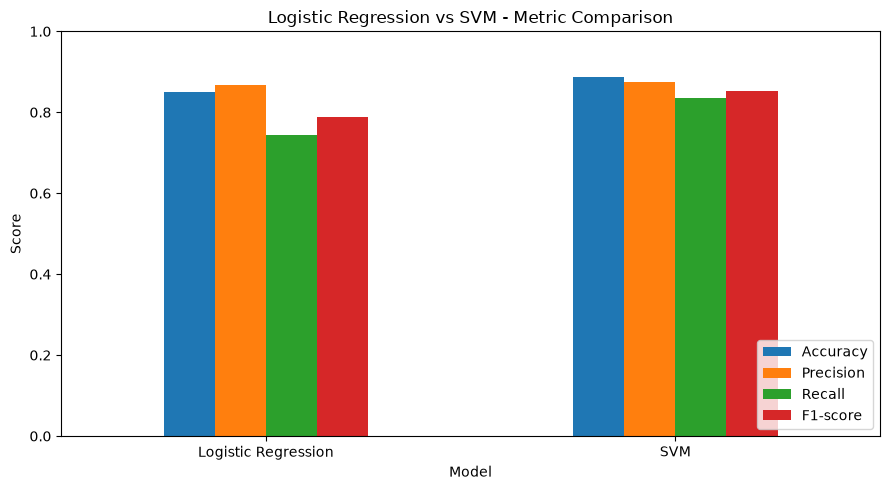


Best model by macro F1-score: SVM


In [49]:
comparison_df = pd.DataFrame([lr_results, svm_results]).set_index('Model')
print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(9,5))
plt.title('Logistic Regression vs SVM - Metric Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_model = comparison_df['F1-score'].idxmax()
print(f"\nBest model by macro F1-score: {best_model}")

# Task 2 - Part B: Deep Learning for Sentiment Analysis (LSTM)

Objective: implement an LSTM model and fairly compare it against the classical models from Part A (Logistic Regression, SVM), using **the same train/test split and random seed**.

In [50]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Tokenize Text Data

We reuse `X_train` / `X_test` / `y_train` / `y_test` produced in Part A (same `train_test_split` call, same `RANDOM_SEED = 42`), so LSTM is trained and evaluated on **exactly the same split** as Logistic Regression and SVM.

In [51]:
VOCAB_SIZE = 10000  # keep the most frequent 10k words

keras_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
keras_tokenizer.fit_on_texts(X_train)

print('Vocabulary size found:', len(keras_tokenizer.word_index))
print('Vocabulary size used (capped):', VOCAB_SIZE)

Vocabulary size found: 13379
Vocabulary size used (capped): 10000


## 2. Convert Text into Sequences

In [52]:
train_sequences = keras_tokenizer.texts_to_sequences(X_train)
test_sequences = keras_tokenizer.texts_to_sequences(X_test)

print('Example text  :', X_train.iloc[0])
print('Example sequence:', train_sequences[0])

Example text  : hate feelings loving city day day little little
Example sequence: [136, 38, 218, 988, 30, 30, 9, 9]


## 3. Apply Padding

In [53]:
seq_lengths = [len(s) for s in train_sequences]
print('Min length:', np.min(seq_lengths))
print('Max length:', np.max(seq_lengths))
print('Mean length:', np.mean(seq_lengths))
print('95th percentile length:', np.percentile(seq_lengths, 95))

# Choose MAX_LEN to comfortably cover ~95% of sequences without excessive padding
MAX_LEN = int(np.percentile(seq_lengths, 95))
print('\nUsing MAX_LEN =', MAX_LEN)

X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

num_classes = df['emotion_label'].nunique()
print('Number of classes:', num_classes)
print('Padded train shape:', X_train_pad.shape)
print('Padded test shape :', X_test_pad.shape)

Min length: 1
Max length: 35
Mean length: 9.30546875
95th percentile length: 20.0

Using MAX_LEN = 20
Number of classes: 6
Padded train shape: (12800, 20)
Padded test shape : (3200, 20)


## 4. Build the LSTM Model

Architecture: trainable **Embedding layer** -> **LSTM** -> **Dropout** (to reduce overfitting) -> Dense softmax output for multi-class emotion classification.

In [54]:
EMBEDDING_DIM = 100

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\avnir\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

A held-out validation split (from the training data only, test set stays untouched) is used to monitor overfitting. Early stopping restores the best weights.

In [55]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train_arr,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 21s 70ms/step - accuracy: 0.3351 - loss: 1.5436 - val_accuracy: 0.3820 - val_loss: 1.2645
Epoch 2/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.4234 - loss: 1.1571 - val_accuracy: 0.4187 - val_loss: 1.2650
Epoch 3/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.4891 - loss: 1.0212 - val_accuracy: 0.4906 - val_loss: 1.1215
Epoch 4/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.5890 - loss: 0.8357 - val_accuracy: 0.6086 - val_loss: 0.9355
Epoch 5/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - accuracy: 0.7185 - loss: 0.6284 - val_accuracy: 0.8023 - val_loss: 0.6660
Epoch 6/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.8935 - loss: 0.3359 - val_accuracy: 0.8500 - val_loss: 0.6246
Epoch 7/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9280 - loss: 0.2376 - val_accuracy: 0.8766 - val_loss: 0.4739
Epoch 8/15
180/180 ━━━━━━━━━━━━━━━━━━━━ 22s 68ms/step - accuracy: 0.9463 - loss: 0.1872 - 

## 6. Training vs Validation Curves

Used as evidence of whether overfitting occurred and whether dropout helped control it.

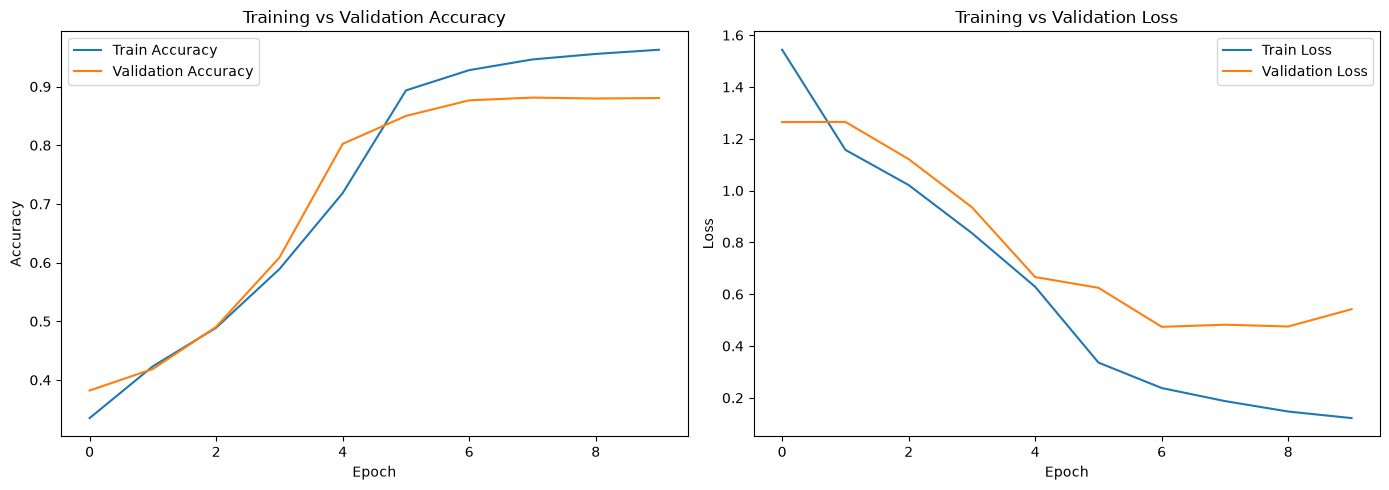

Final train-val accuracy gap: 0.0823
Train and validation accuracy stay close -> dropout and early stopping are controlling overfitting reasonably well.


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f'Final train-val accuracy gap: {gap:.4f}')
if gap > 0.1:
    print('Noticeable gap between train and validation accuracy -> some overfitting remains '
          'despite dropout/early stopping.')
else:
    print('Train and validation accuracy stay close -> dropout and early stopping are '
          'controlling overfitting reasonably well.')

## 7. Evaluate LSTM on the Test Set 

In [57]:
lstm_probs = model.predict(X_test_pad)
lstm_pred = np.argmax(lstm_probs, axis=1)

lstm_results = evaluate_model('LSTM', y_test_arr, lstm_pred)

100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
--- LSTM Results ---
Accuracy : 0.8788
Precision: 0.8251 (macro)
Recall   : 0.8314 (macro)
F1-score : 0.8240 (macro)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       933
           1       0.88      0.86      0.87       432
           2       0.81      0.67      0.73       261
           3       0.56      0.77      0.65       115
           4       0.88      0.83      0.86       387
           5       0.90      0.92      0.91      1072

    accuracy                           0.88      3200
   macro avg       0.83      0.83      0.82      3200
weighted avg       0.88      0.88      0.88      3200



## 8. Final Comparison: Logistic Regression vs SVM vs LSTM

                     Accuracy  Precision  Recall  F1-score
Model                                                     
Logistic Regression    0.8509     0.8680  0.7427    0.7872
SVM                    0.8869     0.8750  0.8344    0.8527
LSTM                   0.8788     0.8251  0.8314    0.8240


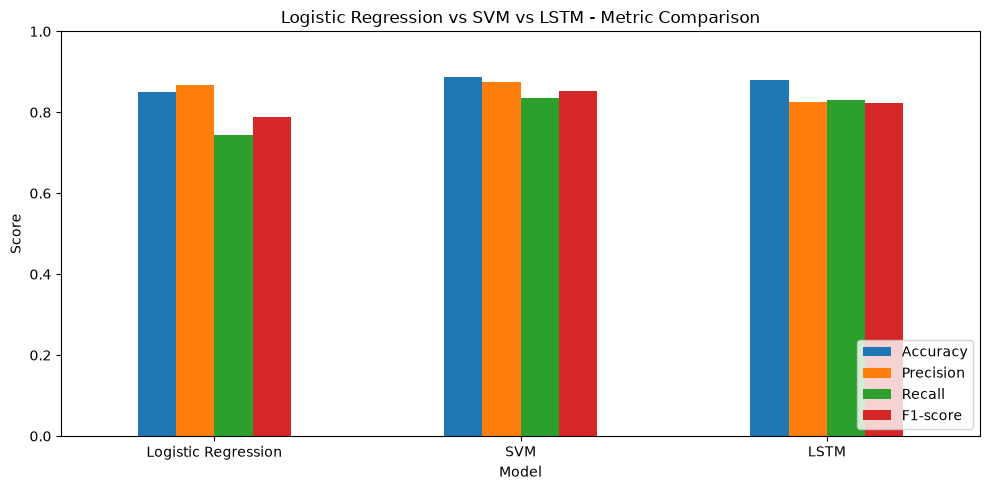


Best classical model: SVM (F1 = 0.8527)
LSTM F1-score: 0.8240
Result: LSTM did NOT beat the best classical model (behind by 0.0287 F1 points).


In [58]:
final_comparison_df = pd.DataFrame([lr_results, svm_results, lstm_results]).set_index('Model')
print(final_comparison_df.round(4))

final_comparison_df.plot(kind='bar', figsize=(10,5))
plt.title('Logistic Regression vs SVM vs LSTM - Metric Comparison')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

best_classical_f1 = max(lr_results['F1-score'], svm_results['F1-score'])
best_classical_name = 'Logistic Regression' if lr_results['F1-score'] >= svm_results['F1-score'] else 'SVM'
lstm_f1 = lstm_results['F1-score']

print(f"\nBest classical model: {best_classical_name} (F1 = {best_classical_f1:.4f})")
print(f"LSTM F1-score: {lstm_f1:.4f}")

if lstm_f1 > best_classical_f1:
    print(f"Result: LSTM EXCEEDED the best classical model by {lstm_f1 - best_classical_f1:.4f} F1 points.")
elif abs(lstm_f1 - best_classical_f1) < 1e-3:
    print("Result: LSTM roughly MATCHED the best classical model.")
else:
    print(f"Result: LSTM did NOT beat the best classical model "
          f"(behind by {best_classical_f1 - lstm_f1:.4f} F1 points).")

## 9. Confusion Matrix for All Models

Confusion matrices for Logistic Regression, SVM, and LSTM, using the human-readable emotion labels.

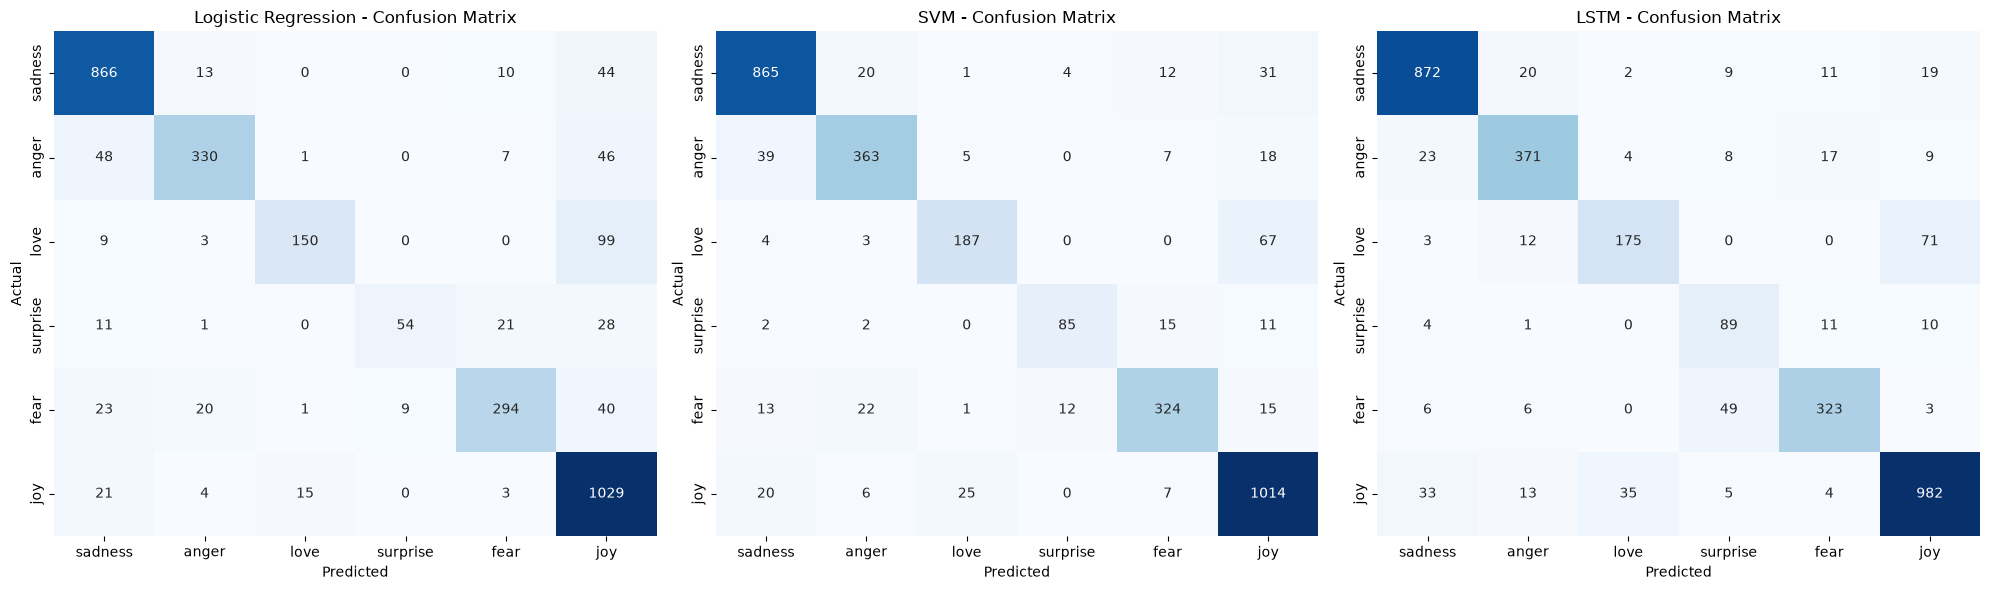

In [59]:
from sklearn.metrics import confusion_matrix

# Map numeric labels back to emotion names for readable axes
label_names = {v: k for k, v in emotion_numbers.items()}
class_labels = [label_names[i] for i in sorted(label_names)]

predictions = {
    'Logistic Regression': log_pred,
    'SVM': svm_pred,
    'LSTM': lstm_pred
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds, labels=sorted(label_names))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels, ax=ax, cbar=False)
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=150, bbox_inches='tight')
plt.show()